In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from idlpy import *
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
from pylab import *

IDL 8.7.2 (linux x86_64 m64).
(c) 2019, Harris Geospatial Solutions, Inc.

Licensed for use by: NIWA - National Institute of Water and Atmospheric Research Ltd - Ashley
License: 335119


In [2]:
'''
Create vegetation land masks
'''
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)


In [3]:
def percentage_of_max(val):
    return((val/mx)*100)

/tmp/ipykernel_3193/3233584483.py:2: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('RdBu_r', 15)
/tmp/ipykernel_3193/3233584483.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  finger_im = xr.apply_ufunc(percentage_of_max, fingerprint_trend).plot(ax=axs[i][1],transform=ccrs.PlateCarree(),vmin=-100,vmax=100,cmap=cm.get_cmap('RdBu', 15),add_colorbar=False)
/tmp/ipykernel_3193/3233584483.py:39: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  finger_im = xr.ap

Text(-0.18, 0.255, 'CAM5 \n(1959-2014)')

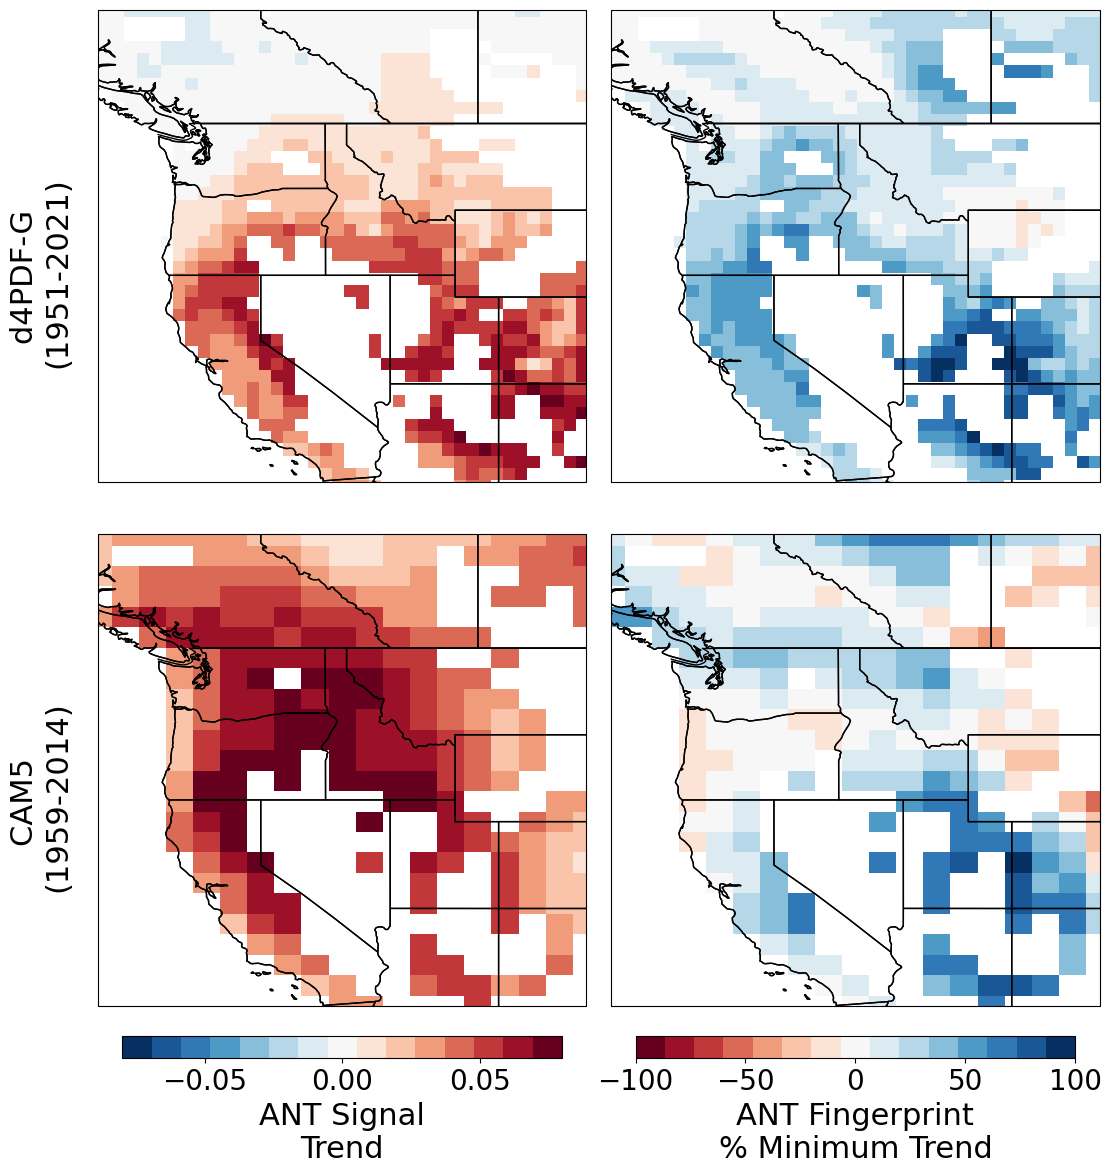

In [7]:
fig,axs = plt.subplots(2,2,figsize=(11,12),subplot_kw=dict(projection=ccrs.PlateCarree()),layout='constrained')
cmap = cm.get_cmap('RdBu_r', 15)

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

for i,model in enumerate(['d4pdf','cam5']):
    
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/'+model+'_resolution/FWI_6month_fire_season_'+model+'_resolution.nc')

    if model == 'cam5':
        scen_dict = {'ALL':'All','NAT':'Nat'}
        start,end = ('1959','2014')
        vege_mask = cam5_vege_mask
        Ant_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc')

    if model == 'd4pdf':
        scen_dict = {'ALL':'HPB','NAT':'HPB_NAT'}
        start,end = ('1951','2021')
        vege_mask = d4pdf_vege_mask
        Ant_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc')

    Ant_da = Ant_da.rename({'FWI':'Ant'})
    Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    Ant_da = Ant_da.where(vege_mask>0)
    Ant_da = Ant_da.where(~era5_da.isnull())
    
    fingerprint_da = xr.open_dataarray('../../'+model+'_fingerprint_'+start+'_'+end+'_take2.nc')
    
    ant_im = xr.apply_ufunc(get_linregress_slope, Ant_da['Ant'], input_core_dims=[["time"]], vectorize = True).plot(ax=axs[i][0],transform=ccrs.PlateCarree(),vmin=-0.08,vmax=0.08,cmap=cmap,add_colorbar=False)
    
    fingerprint_trend = xr.apply_ufunc(get_linregress_slope, fingerprint_da, input_core_dims=[["time"]], vectorize = True)

    mx = fingerprint_trend.min().data.tolist()

    finger_im = xr.apply_ufunc(percentage_of_max, fingerprint_trend).plot(ax=axs[i][1],transform=ccrs.PlateCarree(),vmin=-100,vmax=100,cmap=cm.get_cmap('RdBu', 15),add_colorbar=False)

    for j in range(2):
        axs[i][j].coastlines()  # cartopy function
        axs[i][j].add_feature(cf.BORDERS)
        axs[i][j].add_feature(cf.STATES)
        axs[i][j].set_extent([232.5,255, 32.5,54.18])
    
cb = fig.colorbar(ant_im, ax=axs[0:2, 0], shrink=0.9, orientation='horizontal',pad=0.025)
cb.set_label(label='ANT Signal\nTrend',fontdict=font)
cb.ax.tick_params(labelsize=20)

cb = fig.colorbar(finger_im, ax=axs[0:2, 1], shrink=0.9, orientation='horizontal',pad=0.025)
cb.set_label(label='ANT Fingerprint\n% Minimum Trend',fontdict=font)
cb.ax.tick_params(labelsize=20)
cb.ax.xaxis.offsetText.set(size=16)


axs[0][0].text(-0.18,0.255,'d4PDF-G \n(1951-2021)',fontdict=font,transform=axs[0][0].transAxes, rotation='vertical',ma='center')
axs[1][0].text(-0.18,0.255,'CAM5 \n(1959-2014)',fontdict=font,transform=axs[1][0].transAxes, rotation='vertical',ma='center')

#plt.savefig('../figures/Figure4.png',dpi=300)

In [39]:
'''
create dataset with d4pdf All, Nat, Ant signals and Nat and Ant fingerprints from finger_trans
'''

def save_fingerprint(model,Ant_da,finger_trans,start_year, end_year):

    da = Ant_da.sel(time=slice(start_year,end_year))
    
    pixel = da.stack(pixel=("latitude", "longitude"))
    no_nan = pixel.dropna("pixel", how="all")
    shape = no_nan.Ant.data.shape

    # add fingerprints
    all_finger_trans = np.array([val[0] for val in finger_trans])
    nat_finger_trans = -1*np.array([val[1] for val in finger_trans])
    ant_finger_trans = all_finger_trans - nat_finger_trans

    nat_finger_from_trans = np.transpose(nat_finger_trans)
    ant_finger_from_trans = np.transpose(ant_finger_trans)

    #nat_finger_from_trans = (1/(nat_finger_trans+1)-1)
    #ant_finger_from_trans = (1/(ant_finger_trans+1)-1)

    add_fingers = no_nan.assign(nat_finger_from_trans=(['time','lev','pixel'],nat_finger_from_trans.reshape(shape)),
                                ant_finger_from_trans=(['time','lev','pixel'],ant_finger_from_trans.reshape(shape)),
                                )

    unstack = add_fingers.unstack("pixel")
    
    unstack['ant_finger_from_trans'].to_netcdf(model+'_fingerprint_'+start_year+'_'+end_year+'_take2.nc')
    

    

In [67]:
font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 16,
        }


for i,model in enumerate(['cam5']):#'cam5','d4pdf']):
    
    era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/'+model+'_resolution/FWI_6month_fire_season_'+model+'_resolution.nc')

    if model == 'cam5':
        scen_dict = {'ALL':'All','NAT':'Nat'}
        start,end = ('1959','2014')
        vege_mask = cam5_vege_mask
        Ant_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc')

    if model == 'd4pdf':
        scen_dict = {'ALL':'HPB','NAT':'HPB_NAT'}
        start,end = ('1951','2021')
        vege_mask = d4pdf_vege_mask
        Ant_da = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc')

    Ant_da = Ant_da.rename({'FWI':'Ant'})
    Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
    Ant_da = Ant_da.where(vege_mask>0)
    Ant_da = Ant_da.where(~era5_da.isnull())
    
    
    IDL.retall

    print('getting ALL mean and noise')
    all_ens_mean,noise_all = get_mean_and_noise(model, scen_dict['ALL'], box, vege_mask, start, end)
    print('getting NAT mean and noise')
    nat_ens_mean,noise_nat = get_mean_and_noise(model, scen_dict['NAT'], box, vege_mask, start, end)

    print('getting obs')
    data_obs = get_obs_data(model, box, vege_mask, start, end)
    print('got obs')
    data_scen = np.array([all_ens_mean,nat_ens_mean])

    if model == 'cam5':
        data_noise_1 = np.concatenate((noise_all[:22],noise_nat[:24]))
        data_noise_2 = np.concatenate((noise_all[22:],noise_nat[24:]))

    else:
        data_noise_1 = np.concatenate((noise_all[:50],noise_nat[:50]))
        data_noise_2 = np.concatenate((noise_all[50:],noise_nat[50:]))
        
    print('got arrays')

    if model == 'cam5':
        trunc = 30
    if model == 'd4pdf':
        trunc = 60
        
    IDL.data_obs = data_obs
    IDL.data_scen = data_scen
    IDL.data_noise_1 = data_noise_1
    IDL.data_noise_2 = data_noise_2
    IDL.trunc = trunc
    IDL.finger_trans = 1
    IDL.z_best = 1

    #print('running gendetec')
    IDL.run("gendetec, data_obs, data_scen, data_noise_1, beta_est, \
            data_noise_2=data_noise_2,transform=['1*0','1*0+1*1'], trunc=trunc, finger_trans=finger_trans, \
            z_best=z_best")

    finger_trans = IDL.finger_trans
    z_best = IDL.z_best

    #save_fingerprint(model,Ant_da,finger_trans,start, end)
    
    

getting ALL mean and noise
getting NAT mean and noise
getting obs
got obs
got arrays


In [4]:
def get_obs_data(model, box, vege_mask, start_year, end_year):
    
    if model == 'cam5':
        model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
    else:
        model_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')

    if box != 'full':
        era5_da = era5_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    era5_da = era5_da.where(vege_mask>0)
        
    era5_da = era5_da.sel(time=slice(start_year,end_year))
    era5_da = era5_da.where(~model_da.isnull())
    
    era5_da = era5_da.stack(pixel=("latitude", "longitude"))
    era5_da = era5_da.dropna("pixel", how="all")        
    
    array = era5_da.values.flatten()
        
    return(array)


In [5]:
def get_noise(model,era5_da,scen,ens_mean,box,vege_mask,start_year,end_year):
    
    if model == 'cam5':
        runs = {'All':[i for i in range(1,11)] + [i for i in range(36,44)] + [i for i in range(61,71)] + [i for i in range(86,101)],
                'Nat':[i for i in range(1,11)] + [i for i in range(36,51)] + [i for i in range(61,71)] + [i for i in range(86,96)] + [i for i in range(97,101)]}
    else:
        runs = {'HPB':range(1,101),
                'HPB_NAT':range(1,101)}
    noise = []
    for ens_mem in runs[scen]:
        if ens_mem == 100:
            number = '100'
        else:
            number = '00' + str(ens_mem) if ens_mem < 10 else '0' + str(ens_mem)

        if model == 'cam5':
            mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_run'+number+'.nc')
        elif model == 'd4pdf':
            mem_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_m'+number+'.nc')

        if box != 'full':
            mem_da = mem_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        mem_da = mem_da.where(vege_mask>0)

        mem_da = mem_da.sel(time=slice(start_year,end_year))
        mem_da = mem_da.where(~era5_da.isnull())

        diff = mem_da - ens_mean

        diff = diff.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
        diff = diff.dropna("pixel", how="all")# Drop the pixels that only have NA values.
                
        diff_array = diff.values.flatten()
        noise.append(diff_array)
        
    return(noise)


In [6]:
def get_mean_and_noise(model, scen, box, vege_mask, start_year, end_year):
    
    if model == 'cam5':
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
        ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_'+scen+'_ensMean.nc')
    else:
        era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
        ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_'+scen+'_ensMean.nc')
    
    if box != 'full':
        ens_mean = ens_mean.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

    ens_mean = ens_mean.where(vege_mask>0)
        
    ens_mean = ens_mean.sel(time=slice(start_year,end_year))
    ens_mean = ens_mean.where(~era5_da.isnull())
    
    noise = get_noise(model,era5_da,scen,ens_mean,box,vege_mask,start_year,end_year)

    ens_mean = ens_mean.stack(pixel=("latitude", "longitude"))# Create a MultiIndex
    ens_mean = ens_mean.dropna("pixel", how="all")# Drop the pixels that only have NA values.
    ens_mean_array = ens_mean.values.flatten()
    
    return((ens_mean_array, np.array(noise)))


In [68]:
da = Ant_da.sel(time=slice('1959','2014'))

pixel = da.stack(pixel=("latitude", "longitude"))
no_nan = pixel.dropna("pixel", how="all")
shape = no_nan.Ant.data.shape

# add fingerprints
ant_finger_trans = np.array([val[0] for val in finger_trans])
all_finger_trans = np.array([val[1] for val in finger_trans])
nat_finger_trans = ant_finger_trans + all_finger_trans
real_all_trans = ant_finger_trans + nat_finger_trans

#nat_finger_trans = np.transpose(nat_finger_trans)
#ant_finger_trans = np.transpose(ant_finger_trans)

add_fingers = no_nan.assign(nat_finger_from_trans=(['time','lev','pixel'],nat_finger_trans.reshape(shape)),
                            ant_finger_from_trans=(['time','lev','pixel'],ant_finger_trans.reshape(shape)),
                            all_finger_from_trans=(['time','lev','pixel'],all_finger_trans.reshape(shape)),
                            real_all_finger_from_trans=(['time','lev','pixel'],real_all_trans.reshape(shape)),
                            )

unstack = add_fingers.unstack("pixel")

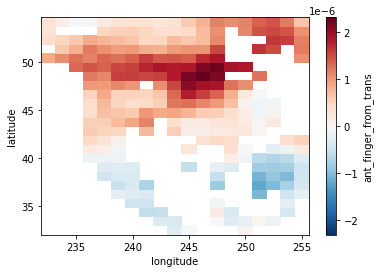

In [69]:
xr.apply_ufunc(get_linregress_slope, unstack.ant_finger_from_trans, input_core_dims=[["time"]], vectorize = True).plot()


In [38]:

da = Ant_da.sel(time=slice('1951','2021'))

pixel = da.stack(pixel=("latitude", "longitude"))
no_nan = pixel.dropna("pixel", how="all")
shape = no_nan.Ant.data.shape

# add fingerprints
ant_finger_trans = np.array([val[0] for val in finger_trans])
all_finger_trans = np.array([val[1] for val in finger_trans])
nat_finger_trans = ant_finger_trans + all_finger_trans
real_all_trans = ant_finger_trans + nat_finger_trans

#nat_finger_trans = np.transpose(nat_finger_trans)
#ant_finger_trans = np.transpose(ant_finger_trans)

add_fingers = no_nan.assign(nat_finger_from_trans=(['time','lev','pixel'],nat_finger_trans.reshape(shape)),
                            ant_finger_from_trans=(['time','lev','pixel'],ant_finger_trans.reshape(shape)),
                            all_finger_from_trans=(['time','lev','pixel'],all_finger_trans.reshape(shape)),
                            real_all_finger_from_trans=(['time','lev','pixel'],real_all_trans.reshape(shape)),
                            )

unstack = add_fingers.unstack("pixel")




In [50]:
xr.apply_ufunc(get_linregress_slope, unstack.ant_finger_from_trans, input_core_dims=[["time"]], vectorize = True).values[0]

array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
         1.38610803e-06,  1.06107307e-06,             nan],
       ...,
       [ 1.08995881e-08,  1.99310260e-08,  3.89576732e-08, ...,
         1.43989852e-07,  1.35259189e-07,  1.29848888e-07],
       [ 1.40761989e-08,  1.33246219e-08,  3.70694229e-09, ...,
         5.15796726e-08,  5.42403609e-08,  7.23524448e-08],
       [-3.42629604e-10, -1.52691558e-08, -1.16081052e-08, ...,
         2.89681563e-08,  3.08197874e-08,  2.77814282e-08]])

In [58]:
ant_trend = xr.apply_ufunc(get_linregress_slope, unstack.ant_finger_from_trans, input_core_dims=[["time"]], vectorize = True).values[0]
ant_trend = ant_trend[~np.isnan(ant_trend)]
nat_trend = xr.apply_ufunc(get_linregress_slope, unstack.nat_finger_from_trans, input_core_dims=[["time"]], vectorize = True).values[0]
nat_trend = nat_trend[~np.isnan(nat_trend)]

np.corrcoef(ant_trend,nat_trend)

array([[ 1.        , -0.94436503],
       [-0.94436503,  1.        ]])

In [57]:
ant_trend

array([[            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
                    nan,             nan,             nan],
       [            nan,             nan,             nan, ...,
         1.38610803e-06,  1.06107307e-06,             nan],
       ...,
       [ 1.08995881e-08,  1.99310260e-08,  3.89576732e-08, ...,
         1.43989852e-07,  1.35259189e-07,  1.29848888e-07],
       [ 1.40761989e-08,  1.33246219e-08,  3.70694229e-09, ...,
         5.15796726e-08,  5.42403609e-08,  7.23524448e-08],
       [-3.42629604e-10, -1.52691558e-08, -1.16081052e-08, ...,
         2.89681563e-08,  3.08197874e-08,  2.77814282e-08]])

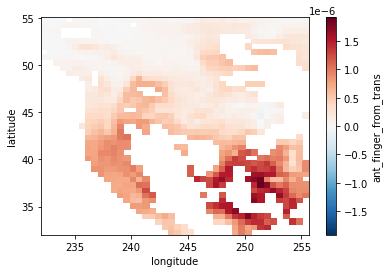

In [34]:
xr.apply_ufunc(get_linregress_slope, unstack.ant_finger_from_trans, input_core_dims=[["time"]], vectorize = True).plot()


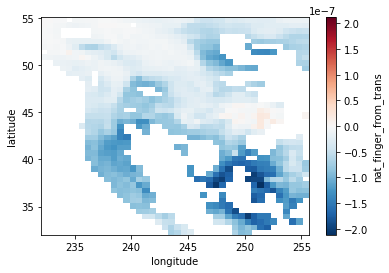

In [35]:
xr.apply_ufunc(get_linregress_slope, unstack.nat_finger_from_trans, input_core_dims=[["time"]], vectorize = True).plot()


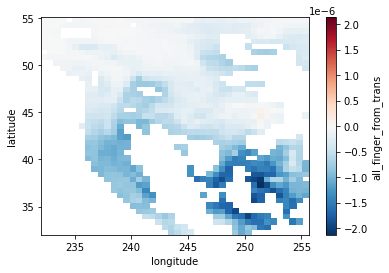

In [36]:
xr.apply_ufunc(get_linregress_slope, unstack.all_finger_from_trans, input_core_dims=[["time"]], vectorize = True).plot()


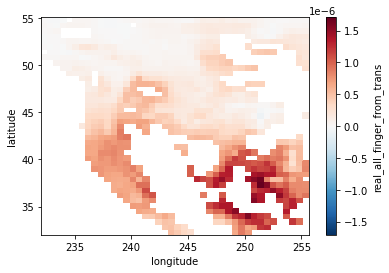

In [40]:
xr.apply_ufunc(get_linregress_slope, unstack.real_all_finger_from_trans, input_core_dims=[["time"]], vectorize = True).plot()


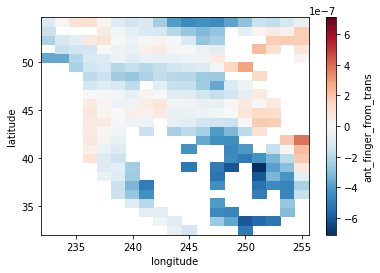

In [30]:
xr.apply_ufunc(get_linregress_slope, unstack.ant_finger_from_trans, input_core_dims=[["time"]], vectorize = True).plot()



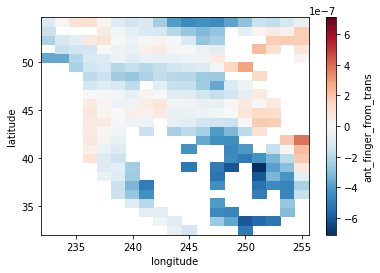

In [33]:
xr.apply_ufunc(get_linregress_slope, unstack.ant_finger_from_trans, input_core_dims=[["time"]], vectorize = True).plot()

In [15]:
data_obs

array([41.56130633, 54.796729  , 60.5219069 , ..., 13.41327304,
       12.71219213, 12.05053084])

In [70]:
IDL.beta_est

array([[2.108019 , 1.1001225],
       [1.7860168, 0.9242113],
       [2.4300213, 1.2760335]], dtype=float32)

In [71]:
np.dot(ant_finger_trans,data_obs)

2.108019357279474

In [72]:
np.dot(nat_finger_trans,data_obs)

1.100122421467273

In [73]:
np.dot(all_finger_trans,data_obs)

-1.0078969358122012

In [63]:
d4pdf_nat = ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc')

In [64]:
cam5_nat = ens_mean = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc')

The history saving thread hit an unexpected error (OperationalError('attempt to write a readonly database',)).History will not be written to the database.


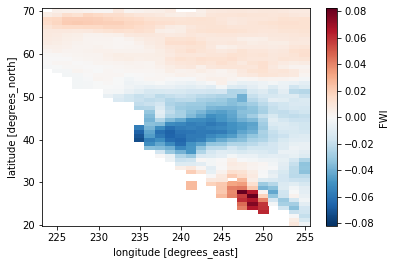

In [65]:
xr.apply_ufunc(get_linregress_slope, d4pdf_nat, input_core_dims=[["time"]], vectorize = True).plot()

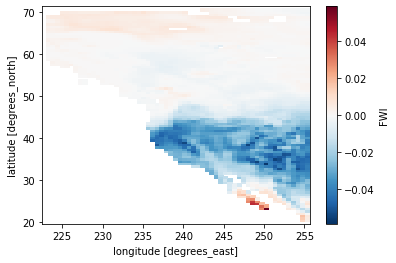

In [66]:
xr.apply_ufunc(get_linregress_slope, cam5_nat, input_core_dims=[["time"]], vectorize = True).plot()